# Kaggle Titanic: 간단한 EDA + 전처리 + GridSearchCV

- 결측치: Age(중앙값), Embarked(최빈값)
- 범주형: Sex, Embarked → one-hot (get_dummies)
- 누수 방지: 결측치 채우는 값(중앙값/최빈값)은 train에서만 계산해서 test에 적용

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
# 1) 데이터 로드
df = pd.read_csv("train.csv")

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
# 2) 간단한 EDA
print("\n결측치:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\n타겟 비율:\n", df["Survived"].value_counts(normalize=True))


결측치:
 Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
dtype: int64

타겟 비율:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [27]:
# 3) 사용 컬럼만 선택
use_cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
df = df[use_cols].copy()

y = df["Survived"]
X = df.drop(columns=["Survived"])

In [28]:
# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
# 5) 결측치 처리 (train 기준으로 값 계산)
age_median = X_train["Age"].median()
emb_mode = X_train["Embarked"].mode()[0]

X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"]  = X_test["Age"].fillna(age_median)

X_train["Embarked"] = X_train["Embarked"].fillna(emb_mode)
X_test["Embarked"]  = X_test["Embarked"].fillna(emb_mode)

In [30]:
# 6) 범주형 원-핫 인코딩 (train 기준 컬럼에 맞춰 test 정렬)
X_train_enc = pd.get_dummies(X_train, columns=["Sex", "Embarked"], drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=["Sex", "Embarked"], drop_first=True)

In [33]:
# train 데이터만 가지고 정보를 보잖아요
# train 데이터에는 없는 범주가 test에 있다면???????

In [31]:
# train의 컬럼 구조에 맞춰 test를 재정렬 (없으면 0으로 채움)
#-> 지금 단계에서는 꼭 안해도 되는데, 만약 train에는 있는 컬럼이 test에는 없다면?
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [32]:
# 8) GridSearchCV (DecisionTree, max_dept)
base_clf = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [None, 2, 3, 4, 5, 7, 10]
}

grid = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_enc, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# 9) test 평가
best_clf = grid.best_estimator_
pred = best_clf.predict(X_test_enc)

print("\nTest Accuracy:", accuracy_score(y_test, pred))




Best Params: {'max_depth': 5}
Best CV Score: 0.8188909681867429

Test Accuracy: 0.7653631284916201


# 과제
1. Wine 데이터를 가지고 92.31% 이상 Accuracy 달성하기 (Validation 기준)
2. best한 hyperparameter가 무엇인지 찾기
- 아래에서 요구하는 세부사항들을 잘 지키면 92.31%는 달성 가능!
- 물론, 추가로 더 하고 싶은 부분은 자유 (전처리, 모델, 하이퍼파라미터 등) -> 당연히 92.31% 넘는 것도 가능

<요구사항>
- 랜덤을 사용하는 모든 함수의 Random State는 42로 고정
- train 데이터와 test 데이터는 계층화 해서 8:2으로 나눌 것
- 의사결정트리 모델을 사용
- "max_depth"라는 하이퍼 파라미터를 None에서 20까지 조절
- cross validation의 fold 수는 5개
- 요구사항 이외의 방법을 써서 성능을 더 올려보기

# 재밌는 얘기
- 머신러닝을 다룰 때 가장 중요한 것은 무엇일까?
- 모든 머신러닝 모델은 -> Data dependent (데이터 의존적)
- 학습이 중요한 키워드 -> Machine Learning

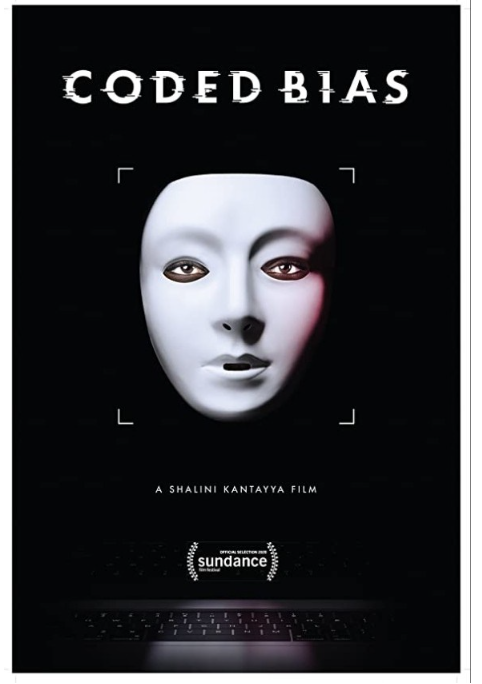

- 2018년 아마존 -> 범죄자 얼굴 인식 프로그램

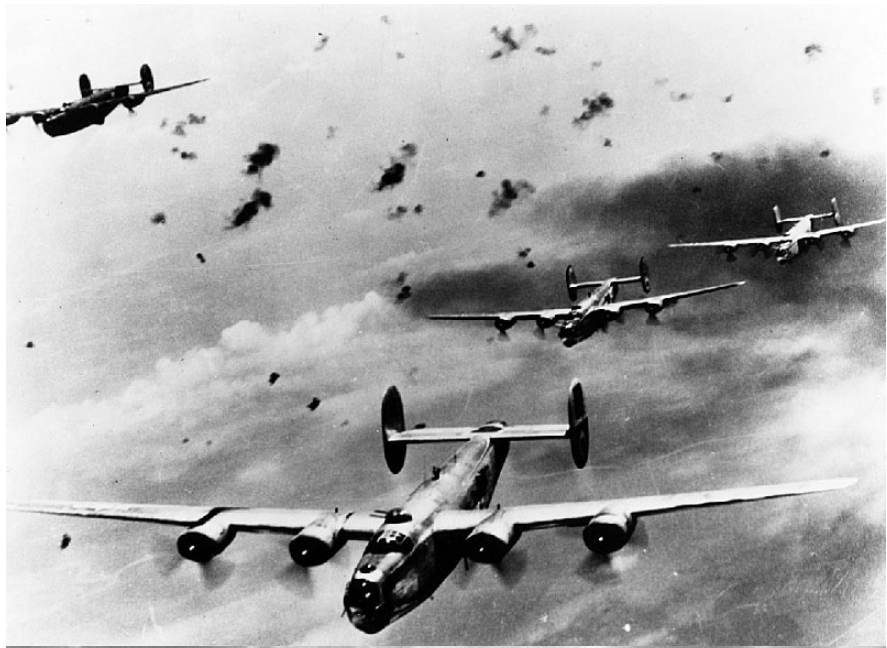

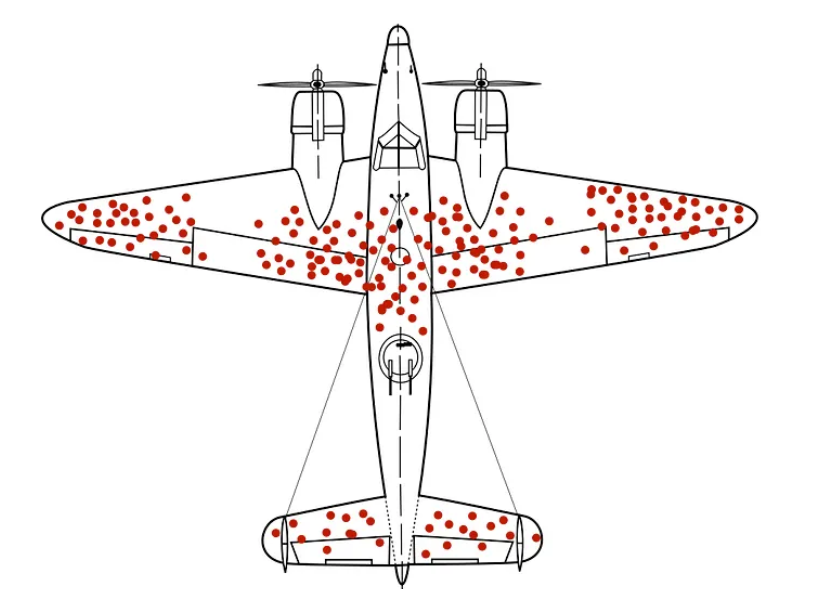

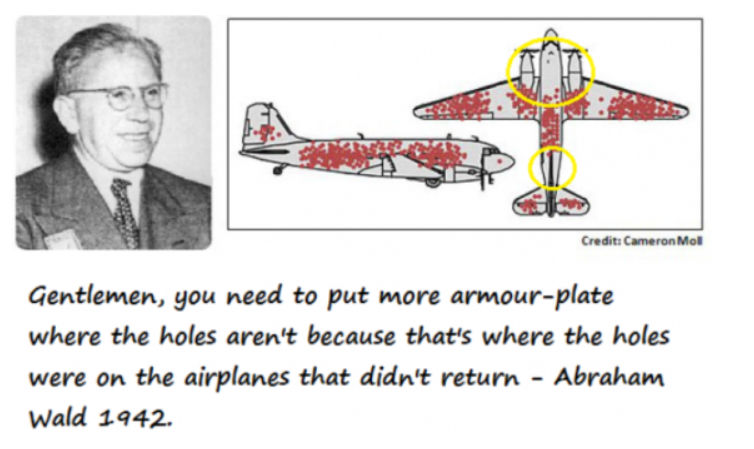

In [34]:
# Survivor Bias